  # Uso de redes generativas para la mejora de la señal astronómica



 El presente "notebook" documenta la extracción y emparejamiento de los datos de Gaia y SDSS.



 Puesto que SDSS tiene menos datos con espectrografía que los que proporciona el crossmatch de Gaia, para mostrar los gráficos usaremos un ejemplo aleatorio de SDSS para mostrar la misma espectrometría para ese objeto en Gaia.cÑw



 El procedimiento será el siguiente:

 1. De Gaia, obtener los mejores crossmatches de Gaia y SDSS

 2. De SDSS, obtener la referencia de la tabla de SDSS con la espectrometría (SpecObj)

 3. De SDSS, seleccionar un ejemplo aleatorio

 4. De SDSS, obtener la espectrometría para el ejemplo obtenido en 3.

 5. De Gaia, obtener la espectrometría para la muestra seleccionada en 1.

 6. De Gaia, filtrar la espectrometría para el objeto obtenido en 3.

 7. De Gaia y SDSS, mostrar los gráficos para el objecto obtenido en 3.

 ## Extracción de los datos

 ### Obtención de una muestra de objetos

  #### Crossmatches Gaia SDSS

  Se seleccionan aleatoriamente los mejores crossmatches entre Gaia y SDSS.

In [ ]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")
gaia_query = gaia_query_template.format(start_index=20001, end_index=100000)

print(f"Executing Step 1: {gaia_query_path.name}...")
gaia_query_job = Gaia.launch_job_async(gaia_query)
gaia_job_results = gaia_query_job.get_results() or Table()

display(gaia_job_results)

Executing Step 1: gaia_sdss_random_subset.adql...
INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
278825364143694592,71.25487167755986,58.57884994117497,13.5869,12.378859,1237667138567471195,0.031962864
364089810816751744,12.635412143809829,35.80630161245867,15.536264,14.468851,1237678894960017649,0.06808887
672149398139884672,116.41340402444385,20.382231289133085,14.614788,13.916077,1237660958104093017,0.035071142
717411412772421760,131.13466227518734,35.45898979737055,14.960042,14.04416,1237658205030383675,0.04167215
766708046667198976,175.74604197186963,39.66326062220025,17.935469,17.046572,1237662225138122895,0.028516946
818326926431384576,141.5426636038266,44.81494282232289,14.274658,13.54316,1237657776619585616,0.05099301
829445978296753024,161.08871978635182,44.908800405802005,16.222876,15.402795,1237660635459944578,0.07095843
886316671044930944,108.34498167303379,29.956750028288273,16.42731,15.41501,1237673738861805766,0.011968112


  #### SDSS - Datos de referencia de objetos

In [46]:
from astroquery.sdss import SDSS
from astropy.io import ascii
from astropy.table import Table
import services.querying as sq

gaia_job_results = gaia_job_results[:200]
gaia_crossmatch_ids = gaia_job_results["original_ext_source_id"]
query_filter_ids = ",".join(gaia_crossmatch_ids.astype(str))

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sq.sanitize_adql(sdss_query_template)
sdss_query = sdss_query_template_sanitized.format(filter_ids=query_filter_ids)

display(sdss_query)
sdss_query_result = SDSS.query_sql(sdss_query, data_release=13)


display(sdss_query_result)



'SELECT s.bestObjID ,s.specObjID ,s.plate ,s.mjd ,s.fiberID ,s.z AS redshift FROM SpecObj AS s WHERE 1=1 AND s.sciencePrimary = 1 AND s.bestObjID IN (1237667138567471195,1237678894960017649,1237660958104093017,1237658205030383675,1237662225138122895,1237657776619585616,1237660635459944578,1237673738861805766,1237663788489048167,1237665429171798345,1237665128021491836,1237662665890595015,1237662503763509661,1237668681530474652,1237666429360472215,1237672005845976281,1237666433651638819,1237680499670188334,1237663230160994515,1237672025708822576,1237672766042735059,1237671939825139833,1237671939287680505,1237663234978286252,1237668678855166217,1237668679929299815,1237678623851217000,1237678580362576124,1237676583734610906,1237676333549027556,1237676482803400902,1237676584272593340,1237671260657221934,1237646379395056324,1237676303496905626,1237673739928535130,1237673705568076283,1237673431225664600,1237651505954750538,1237651736308875540,1237658422483550223,1237667431179944121,1237663543

bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833
1237662530606858510,3837186262545047552,3408,54948,434,-0.0001137369
1237655472900211268,5626168110249545728,4997,55738,168,-8.493909e-05
1237665429171798345,2399437901088712704,2131,53819,528,0.375761


  ### Obtención de los datos de espectrometría

  #### SDSS - Selección ejemplo aleatorio

In [55]:
import random as rnd

sdss_sample_object = rnd.choice(sdss_query_result)

display(sdss_sample_object)


bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237655472900211268,5626168110249545728,4997,55738,168,-8.493909e-05


 #### SDSS - Espectrometría para el ejemplo

In [56]:

sdss_spectra_response = (
    SDSS.get_spectra(
        plate=sdss_sample_object["plate"],
        mjd=sdss_sample_object["mjd"],
        fiberID=sdss_sample_object["fiberID"],
        data_release=13,
    )
    or []
)

# help(sdss_spectra_response)
# dir(sdss_spectra_response)
# print(sdss_spectra_response)

sdss_fits_file = sdss_spectra_response[0]
sdss_spectra_hdu = sdss_fits_file[
    1
]  # La primera tabla después de la cabecera contiene los datos
sdss_spectra_data = sdss_spectra_hdu.data

display(sdss_spectra_data)


FITS_rec([(10.010612 , 3.5518, 0.04665578, 0, 71303168, 1.0822078 , 11.692661 ,  8.423021 , 1.),
          (10.814493 , 3.5519, 0.04743511, 0, 71303168, 1.0825729 , 10.954722 ,  7.854267 , 1.),
          ( 1.3232168, 3.552 , 0.04623859, 0, 71303168, 1.082935  ,  9.930942 ,  6.6964593, 1.),
          ...,
          (58.059307 , 4.0142, 0.12704402, 0, 524288, 0.8578355 ,  7.280325 , 55.30171  , 1.),
          (63.563766 , 4.0143, 0.06619887, 0, 524288, 0.859186  ,  8.355657 , 56.346386 , 1.),
          (52.290478 , 4.0144, 0.11212502, 0, 71827456, 0.85786206,  3.7153409, 56.431675 , 1.)],
         dtype=(numpy.record, [('flux', '>f4'), ('loglam', '>f4'), ('ivar', '>f4'), ('and_mask', '>i4'), ('or_mask', '>i4'), ('wdisp', '>f4'), ('sky', '>f4'), ('model', '>f4'), ('calib_corr', '>f4')]))

 #### Gaia - Espectrometría para la muestra

  Para los datos espectrales debemos usar el [DataLink service](https://astroquery.readthedocs.io/en/latest/gaia/gaia.html#datalink-service-public-and-authenticated)

In [ ]:
source_ids = ",".join(gaia_job_results["source_id"].astype(str))
source_ids = "1265515347877933440"

gaia_spectra_data = Gaia.load_data(
    ids=source_ids,
    data_release="Gaia DR3",
    retrieval_type="XP_SAMPLED",
    # retrieval_type="XP_CONTINUOUS",
    data_structure="INDIVIDUAL",
    format="votable",
    dump_to_file=False,  # Datos en memoria
)

display()

In [39]:
# Grab the very first table from the nested structure
table = list(gaia_spectra_data.values())[0][0].to_table()

# The columns are right there
print(table.colnames)


IndexError: list index out of range

 #### Gaia - Espectrometría para el ejemplo

 Obtenemos la referencia en Gaia para el objecto de muestra de SDSS

In [57]:
gaia_sample_object = gaia_job_results[
    gaia_job_results["original_ext_source_id"] == sdss_sample_object["bestObjID"]
]

display(gaia_sample_object)

gaia_sample_object_source_id = gaia_sample_object["source_id"].item()

display(type(gaia_sample_object_source_id))
display(gaia_sample_object_source_id)


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
1308974472679778304,257.45075277225425,29.57907119791902,17.45626,15.876958,1237655472900211268,0.02533424


int

1308974472679778304

 Y obtenemos la espctrometría para esa referencia.

In [58]:
import gaiaxpy
import astropy.units as u
from specutils import Spectrum

# 1. Calibrate functionally using gaiaxpy
source_ids = [gaia_sample_object_source_id]
calibrated_spectra, sampling_grid = gaiaxpy.calibrate(source_ids)

# 2. Extract arrays and attach Astropy units
flux_array = calibrated_spectra["flux"].iloc[0]
wavelength_qty = sampling_grid * u.nm
flux_qty = flux_array * (u.W / (u.m**2 * u.nm))

# 3. Instantiate the standard specutils Spectrum1D object
gaia_object_spectrum = Spectrum(flux=flux_qty, spectral_axis=wavelength_qty)

display(gaia_object_spectrum)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


<Spectrum(flux=[1.4356017629514667e-18 ... 6.573251261677453e-18] W / (nm m2) (shape=(343,), mean=0.00000 W / (nm m2)); spectral_axis=<SpectralAxis [ 336.  338.  340. ... 1016. 1018. 1020.] nm> (length=343))>

 ### Gráficos comparativos

 #### SDSS - Flujo y Longitud de Onda para una objeto

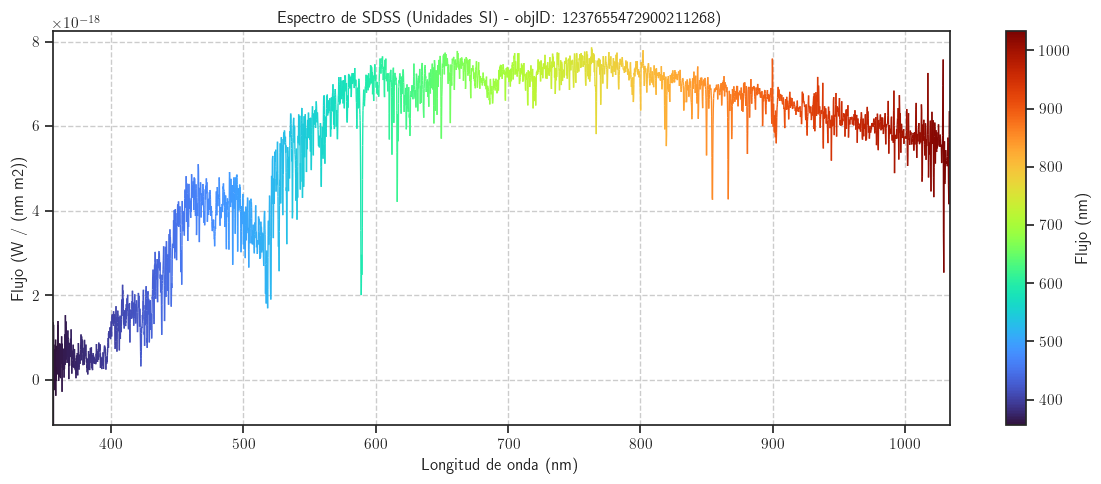

In [59]:
from services.sdss import parse_to_si
from services.plotting import plot_physical_spectrum

wavelength = sdss_spectra_data["loglam"]
flux = sdss_spectra_data["flux"]

sdss_spectrum_si = parse_to_si(wavelength, flux)

plot_physical_spectrum(
    spectrum=sdss_spectrum_si,
    title=f"Espectro de SDSS (Unidades SI) - objID: {sdss_sample_object['bestObjID']})",
)



 #### Gaia - Flujo y Longitud de Onda para una objeto

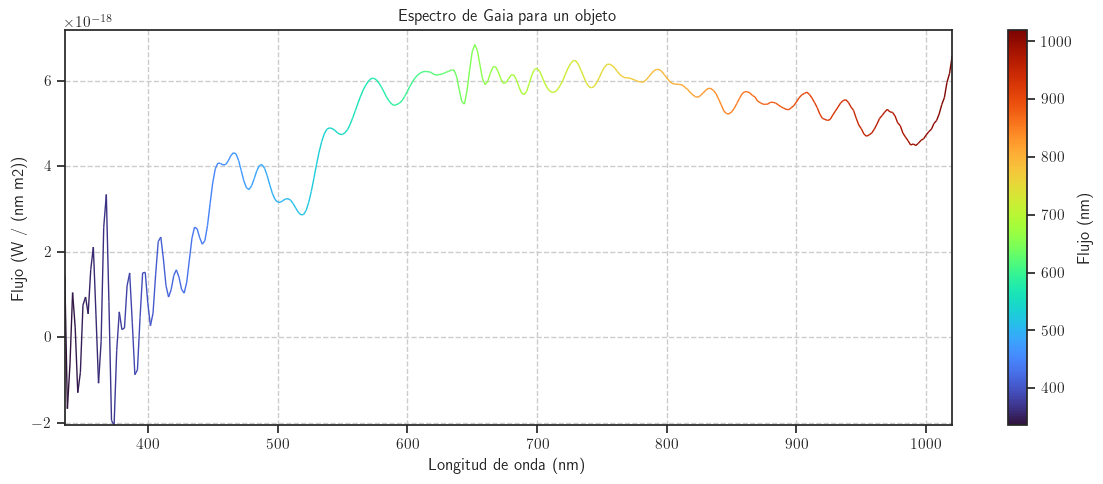

In [60]:
import services.plotting as spl
from specutils import Spectrum
import astropy.units as u

spl.plot_physical_spectrum(
    spectrum=gaia_object_spectrum, title="Espectro de Gaia para un objeto"
)

# # %% [markdown]
# # #### Gaia - Flujo y Longitud de Onda para múltiples objetos

# # %%
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = pd.concat(
#     [
#         v[0].to_table().to_pandas().assign(source=key.split()[-1].replace(".xml", ""))
#         for key, v in gaia_spectra_data.items()
#     ],
#     ignore_index=True,
# )

# sns.lineplot(data=df, x="wavelength", y="flux", hue="source")
# plt.show()
